# Phase 4 - Assumption Testing

## Objectives

Before performing hypothesis testing, the statistical assumptions are validated to ensure that the selected tests are appropriate.

### Assumption Tests

- Normality Test (Shapiro-Wilk)
- Homogeneity of Variance (Levene Test)
- Independence Check
- Correlation Analysis
- Multicollinearity Check (VIF)

### Visualizations

- QQ Plot
- Residual Plot
- Pair Plot
- Correlation Matrix

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import levene

from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("processed_hotel_bookings.csv")

In [3]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [4]:
sample = df["adr"].sample(5000, random_state=42)

In [5]:
#Shapiro-Wilk Test
stat, p = shapiro(sample)

print("Statistic :", stat)
print("P-value :", p)

if p > 0.05:
    print("Data is Normally Distributed")
else:
    print("Data is NOT Normally Distributed")

Statistic : 0.9845852450129778
P-value : 6.061331160500354e-23
Data is NOT Normally Distributed


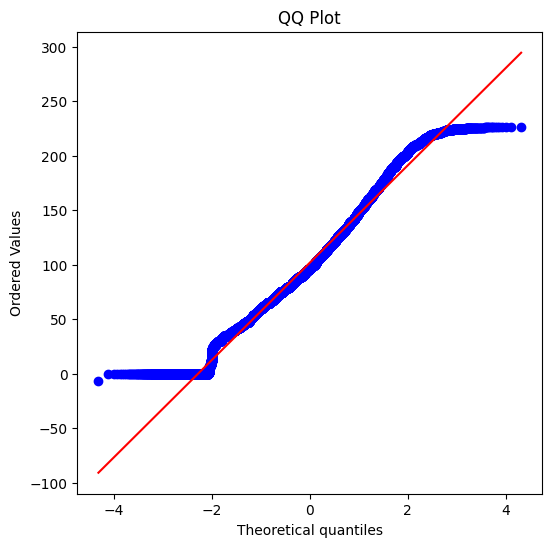

In [6]:
#QQ Plot
plt.figure(figsize=(6,6))

stats.probplot(df["adr"], dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()

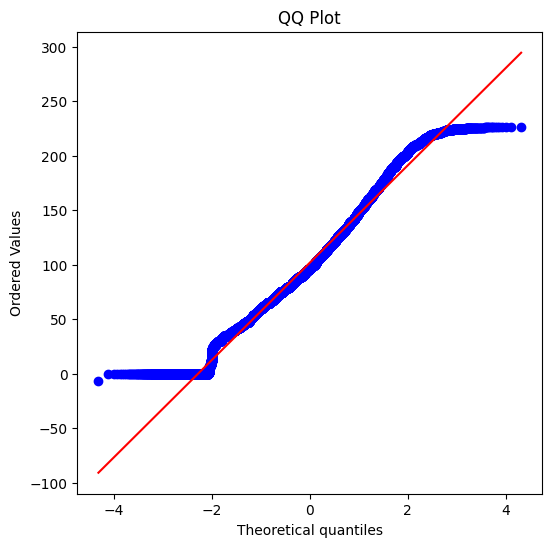

In [7]:
#QQ Plot
plt.figure(figsize=(6,6))

stats.probplot(df["adr"], dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()

In [8]:
#Homogeneity of Variance

city = df[df["hotel"] == 0]["adr"]

resort = df[df["hotel"] == 1]["adr"]

#Levene Test
stat, p = levene(city, resort)

print("Statistic :", stat)
print("P-value :", p)

if p > 0.05:
    print("Equal Variance Assumed")
else:
    print("Variance is Not Equal")

Statistic : 3113.000750356535
P-value : 0.0
Variance is Not Equal


In [9]:
#Independence Check

print("Checking duplicate observations...")

print("Duplicate Rows :", df.duplicated().sum())

print("Rows :", len(df))

print("Unique Rows :", len(df.drop_duplicates()))

Checking duplicate observations...
Duplicate Rows : 0
Rows : 84705
Unique Rows : 84705


In [10]:
#Correlation Analysis

corr = df.select_dtypes(include=["int64","float64"]).corr()

corr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,total_stay,total_guests,average_daily_revenue
hotel,1.000000,-0.080748,0.030430,-0.089362,0.002688,0.009170,0.007096,0.158382,0.212266,-0.011978,...,0.095075,-0.034042,-0.038740,-0.201758,0.215780,-0.026913,0.065551,0.217181,-0.001477,0.107482
is_canceled,-0.080748,1.000000,0.184630,0.084504,-0.041602,-0.000233,0.004250,0.057594,0.080817,0.080218,...,-0.075468,0.005570,-0.029538,0.133029,-0.180255,-0.115590,-0.886545,0.081675,0.094023,0.132781
lead_time,0.030430,0.184630,1.000000,0.141394,0.013887,0.102686,0.010821,0.234635,0.312816,0.143107,...,-0.080104,0.133022,0.055907,0.038291,-0.087949,0.036033,-0.195144,0.320518,0.132274,0.268171
arrival_date_year,-0.089362,0.084504,0.141394,1.000000,-0.233745,-0.524409,-0.011326,0.003034,0.000380,0.031460,...,0.024679,-0.026669,0.061079,0.166480,-0.042320,0.059997,-0.087704,0.001418,0.032282,0.075600
arrival_date_month,0.002688,-0.041602,0.013887,-0.233745,1.000000,0.275798,-0.017522,-0.020653,-0.017125,-0.052069,...,0.041256,0.024967,-0.014706,-0.090526,0.001435,-0.022392,0.040244,-0.020469,-0.079323,-0.088012
arrival_date_week_number,0.009170,-0.000233,0.102686,-0.524409,0.275798,1.000000,0.091875,0.026241,0.026811,0.021578,...,-0.021000,0.013236,-0.057710,0.092991,0.005619,0.044520,-0.008004,0.029765,0.021877,0.071357
arrival_date_day_of_month,0.007096,0.004250,0.010821,-0.011326,-0.017522,0.091875,1.000000,-0.017792,-0.028542,-0.001845,...,-0.000263,0.005781,0.016869,0.019582,0.007877,-0.002949,-0.002561,-0.027891,0.006599,-0.013029
stays_in_weekend_nights,0.158382,0.057594,0.234635,0.003034,-0.020653,0.026241,-0.017792,1.000000,0.550530,0.092674,...,-0.092018,-0.031858,-0.118593,0.037002,-0.045881,0.032699,-0.049811,0.783784,0.092118,0.614456
stays_in_week_nights,0.212266,0.080817,0.312816,0.000380,-0.017125,0.026811,-0.028542,0.550530,1.000000,0.099370,...,-0.066553,0.002443,-0.136120,0.048097,-0.047949,0.037346,-0.073771,0.949945,0.098555,0.744175
adults,-0.011978,0.080218,0.143107,0.031460,-0.052069,0.021578,-0.001845,0.092674,0.099370,1.000000,...,-0.174207,-0.014117,-0.099260,0.250060,0.001455,0.113206,-0.091146,0.108605,0.823681,0.192531


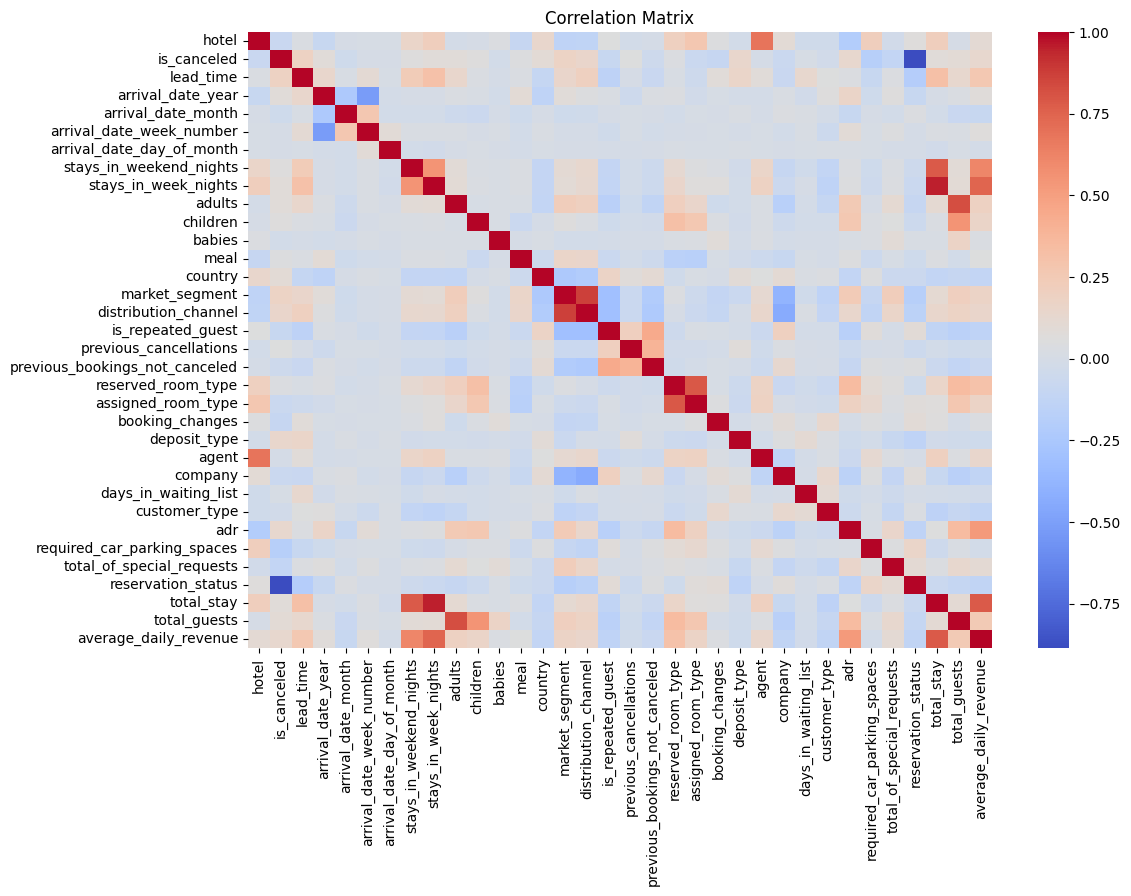

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

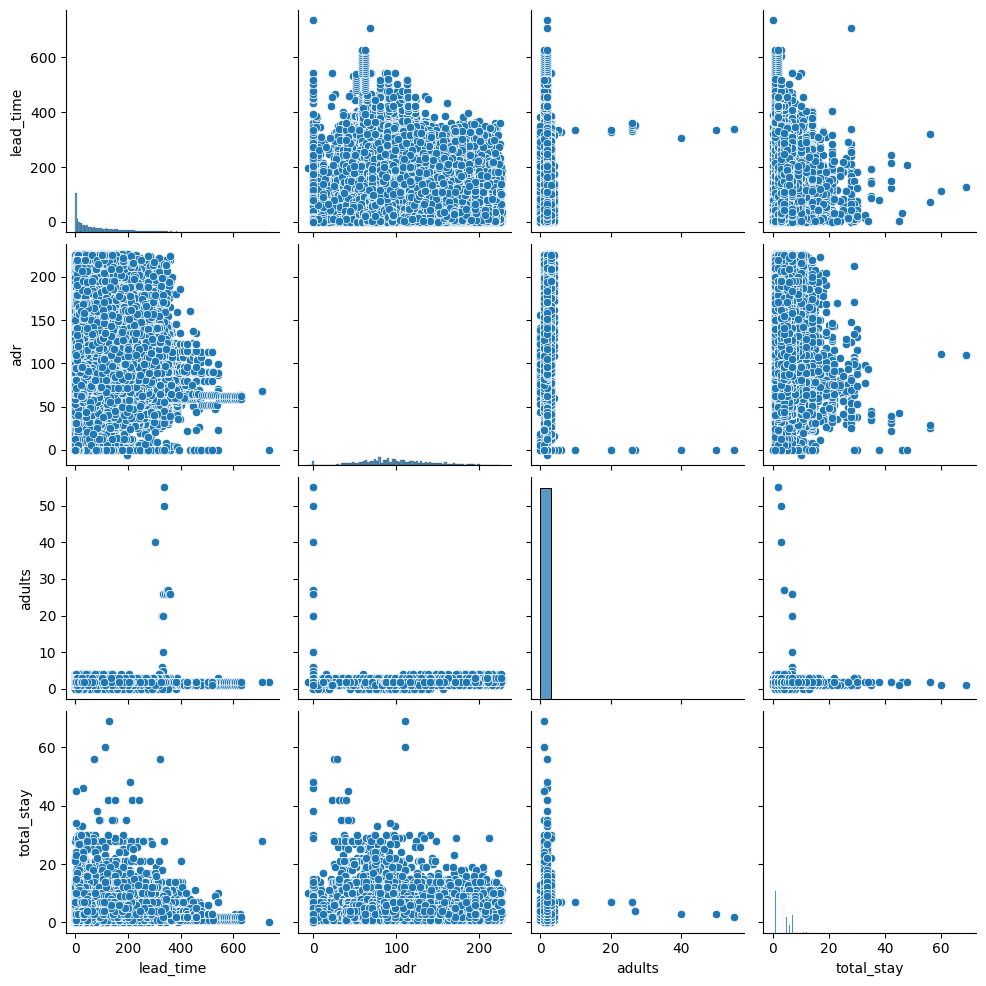

In [14]:
#Pair Plot

pair_columns = [
    "lead_time",
    "adr",
    "adults",
    "total_stay"
]

sns.pairplot(df[pair_columns])

plt.show()

In [15]:
!pip install statsmodels

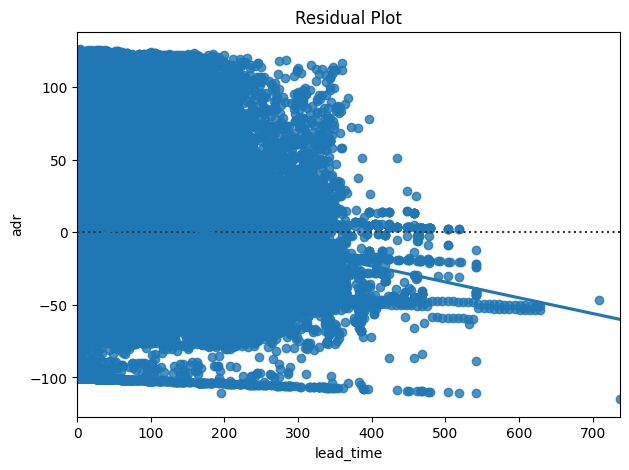

In [16]:
#Residual Plot

plt.figure(figsize=(7,5))

sns.residplot(
    x=df["lead_time"],
    y=df["adr"],
    lowess=True
)

plt.title("Residual Plot")

plt.show()

In [17]:
#Multicollinearity

features = df[
[
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "total_stay"
]]

#VIF Calculation
vif = pd.DataFrame()

vif["Feature"] = features.columns

vif["VIF"] = [
    variance_inflation_factor(
        features.values,
        i
    )
    for i in range(features.shape[1])
]

vif

,Feature,VIF
0,lead_time,2.095851
1,adr,5.811730
2,adults,6.470335
3,children,1.162745
4,babies,1.009762
5,total_stay,2.895289


In [18]:
#Assumption Summary

summary = pd.DataFrame({

"Assumption":[
"Normality",
"Homogeneity",
"Independence",
"Correlation",
"Multicollinearity"
],

"Method":[
"Shapiro-Wilk",
"Levene Test",
"Duplicate Check",
"Pearson Correlation",
"VIF"
]

})

summary

,Assumption,Method
0,Normality,Shapiro-Wilk
1,Homogeneity,Levene Test
2,Independence,Duplicate Check
3,Correlation,Pearson Correlation
4,Multicollinearity,VIF
